# FTIR Automated KPI Report

Field Technical Information Report (FTIR) analysis for 2021–2026 field claims.
The notebook cleans the extract, draws the KPI charts, and writes an editable PowerPoint deck (native charts, not pictures).

**Definitions used throughout**

| Term | Rule |
|---|---|
| Failure | `fc_ok == "NG"` |
| Resolved | `problem_solved == "Yes"` |
| Usage kilometres | `using_time_km` parsed to an integer (`using_km_int`) |
| Usage bucket | 5,000 km bands: `0–5000`, `5001–10000`, … |
| Months in service | `days_used // 30` |
| Investigation lag | `judgement_date − ftir_report_date`, in days |

Place the extract in `data/` as `ftir_dataset.csv`, `ftir_dataset.db`, or `records.csv`.


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)
from pptx import Presentation
from pptx.chart.data import CategoryChartData
from pptx.dml.color import RGBColor
from pptx.enum.chart import XL_CHART_TYPE, XL_LEGEND_POSITION
from pptx.enum.shapes import MSO_SHAPE
from pptx.enum.text import PP_ALIGN
from pptx.util import Emu, Inches, Pt

pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

NAVY = "#0B3A5B"
TEAL = "#1F7A8C"
AMBER = "#E08A2A"
GREEN = "#1E8C5A"
RED = "#C0392B"
SLATE = "#5D6D7E"
INK = "#1C2833"

plt.rcParams.update({
    "figure.figsize": (11, 4.6),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D5D8DC",
    "axes.labelcolor": INK,
    "axes.titleweight": "semibold",
    "axes.titlesize": 13,
    "axes.titlecolor": NAVY,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E5E8EB",
    "grid.linewidth": 0.6,
    "font.size": 11,
    "xtick.color": INK,
    "ytick.color": INK,
})


def find_dataset() -> Path:
    """Prefer ftir_dataset.csv / .db, then records.csv, walking up from the cwd."""
    names = ("ftir_dataset.csv", "ftir_dataset.db", "records.csv")
    roots = [Path.cwd(), *Path.cwd().parents]
    for root in roots:
        for name in names:
            candidate = root / "data" / name
            if candidate.is_file():
                return candidate
    searched = [str(r / "data") for r in roots]
    raise FileNotFoundError(
        "No FTIR extract found. Looked for ftir_dataset.csv, ftir_dataset.db, "
        f"or records.csv under: {searched}"
    )


def load_ftir(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".db":
        import sqlite3
        with sqlite3.connect(path) as con:
            tables = pd.read_sql(
                "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'",
                con,
            )
            if tables.empty:
                raise ValueError(f"No tables in {path}")
            names = tables["name"].tolist()
            chosen = names[0]
            for name in names:
                cols = pd.read_sql(f"SELECT * FROM {name} LIMIT 0", con).columns
                if "ftir_report_date" in cols:
                    chosen = name
                    break
            frame = pd.read_sql(f"SELECT * FROM {chosen}", con)
        print(f"Loaded {len(frame):,} rows from {path} (table {chosen})")
        return frame
    frame = pd.read_csv(path, low_memory=False)
    print(f"Loaded {len(frame):,} rows from {path}")
    return frame


## Load and clean

`using_time_km` arrives as a number or as text (`10,894 km`, `24.2k km`, `3637 km / 160 days`). All of those become `using_km_int`.
Report year and month are taken from `ftir_report_date`, overwriting any pre-computed columns so the dates stay the source of truth.


In [12]:
def parse_km(value):
    """Accept 10894, '10,894 km', '24.2k km', '7,609 Km.', and '3637 km / 160 days'."""
    if pd.isna(value):
        return pd.NA
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        return int(round(value))
    text = str(value).lower().replace(",", "").strip()
    text = text.split("/")[0]
    text = text.replace("km.", " ").replace("km", " ")
    text = " ".join(text.split()).rstrip(".")
    if text in {"", "nan", "none"}:
        return pd.NA
    if text.endswith("k"):
        return int(round(float(text[:-1]) * 1000))
    return int(round(float(text)))


def km_bucket(km) -> str:
    """5,000 km bands labelled 0–5000, 5001–10000, 10001–15000, ..."""
    if pd.isna(km):
        return "Unknown"
    km = int(km)
    if km <= 5000:
        return "0–5000"
    upper = ((km - 1) // 5000 + 1) * 5000
    lower = upper - 4999
    return f"{lower}–{upper}"


def bucket_lower(label: str) -> int:
    if label in {"Unknown", "40001+"}:
        return 10**9 if label == "40001+" else -1
    return int(str(label).split("–")[0])


def chart_km_bucket(label: str) -> str:
    """Keep every 5,000 km band through 40,000 km; fold the long tail for the chart."""
    if label == "Unknown":
        return "Unknown"
    if bucket_lower(label) >= 40001:
        return "40001+"
    return label


DATA_PATH = find_dataset()
raw = load_ftir(DATA_PATH)
df = raw.copy()

df["using_km_int"] = df["using_time_km"].map(parse_km).astype("Int64")
df["usage_bucket"] = df["using_km_int"].map(km_bucket)
df["usage_bucket_chart"] = df["usage_bucket"].map(chart_km_bucket)

df["days_used"] = pd.to_numeric(df["days_used"], errors="coerce")
df["months_used"] = (df["days_used"] // 30).astype("Int64")

df["ftir_report_date"] = pd.to_datetime(df["ftir_report_date"], errors="coerce")
df["judgement_date"] = pd.to_datetime(df["judgement_date"], errors="coerce")
df["report_year"] = df["ftir_report_date"].dt.year.astype("Int64")
df["report_month"] = df["ftir_report_date"].dt.month.astype("Int64")
df["report_label"] = df["ftir_report_date"].dt.strftime("%Y-%b")

df["fc_ok"] = df["fc_ok"].astype("string").str.strip().str.upper()
df["rank"] = df["rank"].astype("string").str.strip().str.upper()
df["problem_solved"] = df["problem_solved"].astype("string").str.strip()
df["is_resolved"] = df["problem_solved"].fillna("").str.lower().eq("yes").astype(int)
df["investigation_lag_days"] = (df["judgement_date"] - df["ftir_report_date"]).dt.days

df["plant"] = df["manufacturer_factory"].fillna("Unknown").astype(str).str.strip()
df["c_measure"] = df["c_measure"].fillna("Not recorded").astype(str).str.strip()
df["sales_dealer"] = df["sales_dealer"].fillna("Unknown").astype(str).str.strip()
df["service_dealer"] = df["service_dealer"].fillna("Unknown").astype(str).str.strip()

print(f"Rows: {len(df):,}")
print(f"Report dates: {df['ftir_report_date'].min():%Y-%m-%d} → {df['ftir_report_date'].max():%Y-%m-%d}")
print(f"using_km_int missing: {int(df['using_km_int'].isna().sum()):,}")
print(f"judgement_date missing: {int(df['judgement_date'].isna().sum()):,}")
df[["ftir_no", "fc_ok", "plant", "using_km_int", "usage_bucket", "days_used", "months_used",
    "report_year", "report_month", "rank", "is_resolved"]].head(3)


Loaded 50,000 rows from d:\MQIH2\data\records.csv
Rows: 50,000
Report dates: 2021-01-01 → 2026-10-07
using_km_int missing: 0
judgement_date missing: 3,404


,ftir_no,fc_ok,plant,using_km_int,usage_bucket,days_used,months_used,report_year,report_month,rank,is_resolved
0,FTIR-2022-000001,NG,Oragadam Plant,30589,30001–35000,1800,60,2022,7,B,0
1,FTIR-2021-000002,OK,Chennai Plant,10894,10001–15000,167,5,2021,5,B,0
2,FTIR-2026-000003,NG,Tochigi Plant,2803,0–5000,30,1,2026,6,B,0


## KPIs

Failures are NG judgements. Resolution is `problem_solved = Yes`. Complaint frequency is the count of FTIR rows in each usage bucket (this extract is a complaint file, not a vehicle parc, so the buckets are mix of reported cases rather than a failure rate per vehicle).


In [13]:
failures = df[df["fc_ok"] == "NG"]
n = len(df)
n_fail = len(failures)

plant_counts = df["plant"].value_counts()
plant_fail = failures["plant"].value_counts()
plant_fail_pct = (plant_fail / n_fail).rename("pct_of_failures")
plant_kpi = (
    pd.DataFrame({"complaints": plant_counts, "failures_ng": plant_fail})
    .fillna(0)
    .astype(int)
)
plant_kpi["pct_of_failures"] = plant_kpi["failures_ng"] / n_fail
plant_kpi = plant_kpi.sort_values("failures_ng", ascending=False)

usage_kpi = (
    df.groupby("usage_bucket", dropna=False)
    .agg(complaints=("ftir_no", "size"), failures_ng=("fc_ok", lambda s: int((s == "NG").sum())),
         resolved=("is_resolved", "sum"))
    .reset_index()
)
usage_kpi["bucket_order"] = usage_kpi["usage_bucket"].map(bucket_lower)
usage_kpi = usage_kpi.sort_values("bucket_order")
usage_kpi["pct_of_complaints"] = usage_kpi["complaints"] / n
usage_kpi = usage_kpi.drop(columns="bucket_order")

month_kpi = (
    df.dropna(subset=["months_used"])
    .groupby("months_used")
    .agg(complaints=("ftir_no", "size"), resolved=("is_resolved", "sum"))
    .reset_index()
)
month_kpi["resolution_rate"] = month_kpi["resolved"] / month_kpi["complaints"]
month_kpi["months_used"] = month_kpi["months_used"].astype(int)

rank_kpi = df["rank"].value_counts(dropna=False).rename_axis("rank").reset_index(name="complaints")
rank_kpi["pct"] = rank_kpi["complaints"] / n
rank_order = {"A": 0, "B": 1, "C": 2}
rank_kpi["_ord"] = rank_kpi["rank"].map(lambda r: rank_order.get(str(r), 9))
rank_kpi = rank_kpi.sort_values("_ord").drop(columns="_ord")

sales_counts = df["sales_dealer"].value_counts().rename("sales_dealer_complaints")
service_counts = df["service_dealer"].value_counts().rename("service_dealer_complaints")
dealer_kpi = pd.concat([sales_counts, service_counts], axis=1).fillna(0).astype(int)
dealer_kpi["total_mentions"] = dealer_kpi.sum(axis=1)
dealer_kpi = dealer_kpi.sort_values("total_mentions", ascending=False)

measure_kpi = pd.crosstab(df["c_measure"], df["problem_solved"].fillna("Unknown"), dropna=False)
for col in ("Yes", "Partially", "No"):
    if col not in measure_kpi.columns:
        measure_kpi[col] = 0
measure_kpi["complaints"] = measure_kpi.sum(axis=1)
measure_kpi["success_rate"] = measure_kpi["Yes"] / measure_kpi["complaints"]
measure_kpi = measure_kpi.sort_values("complaints", ascending=False)

lag = df["investigation_lag_days"].dropna()
lag = lag[lag >= 0]

early = df.loc[df["months_used"] <= 12, "is_resolved"]
late = df.loc[df["months_used"] > 12, "is_resolved"]
action_mask = df["c_measure"] != "No action - within spec"

top_plant = plant_kpi.index[0]
top_rank_row = rank_kpi.iloc[0]

kpi = {
    "n": n,
    "n_fail": n_fail,
    "fail_rate": n_fail / n,
    "date_min": df["ftir_report_date"].min(),
    "date_max": df["ftir_report_date"].max(),
    "top_failure_plant": top_plant,
    "top_failure_share": float(plant_kpi.loc[top_plant, "pct_of_failures"]),
    "top_failure_count": int(plant_kpi.loc[top_plant, "failures_ng"]),
    "share_le_10k": float((df["using_km_int"] <= 10000).mean()),
    "share_gt_20k": float((df["using_km_int"] > 20000).mean()),
    "top_usage_bucket": usage_kpi.iloc[0]["usage_bucket"],
    "top_usage_share": float(usage_kpi.iloc[0]["pct_of_complaints"]),
    "resolution_rate": float(df["is_resolved"].mean()),
    "resolution_0_12": float(early.mean()),
    "resolution_13_plus": float(late.mean()),
    "n_0_12": int(early.shape[0]),
    "n_13_plus": int(late.shape[0]),
    "top_rank": str(top_rank_row["rank"]),
    "top_rank_share": float(top_rank_row["pct"]),
    "rank_shares": {str(r): float(p) for r, p in zip(rank_kpi["rank"], rank_kpi["pct"])},
    "top_sales_dealer": sales_counts.index[0],
    "top_sales_count": int(sales_counts.iloc[0]),
    "top_service_dealer": service_counts.index[0],
    "top_service_count": int(service_counts.iloc[0]),
    "same_dealer_share": float((df["sales_dealer"] == df["service_dealer"]).mean()),
    "action_rate": float(action_mask.mean()),
    "action_solved": float(df.loc[action_mask, "is_resolved"].mean()),
    "no_action_solved": float(df.loc[~action_mask, "is_resolved"].mean()) if (~action_mask).any() else float("nan"),
    "solved_rate": float(df["is_resolved"].mean()),
    "avg_lag": float(lag.mean()),
    "median_lag": float(lag.median()),
    "n_lag": int(lag.shape[0]),
}

print("Failures (NG) by plant")
display_plant = plant_kpi.copy()
display_plant["pct_of_failures"] = (display_plant["pct_of_failures"] * 100).round(1)
display_plant


Failures (NG) by plant


,complaints,failures_ng,pct_of_failures
plant,,,
Chennai Plant,22672,5347,45.2
Oragadam Plant,11064,2581,21.8
Tochigi Plant,7207,1710,14.5
Kyushu Plant,4962,1192,10.1
Purwakarta Plant,2190,537,4.5
Rosslyn Plant,1905,454,3.8


In [14]:
print("Complaint frequency by usage bucket")
usage_view = usage_kpi.copy()
usage_view["pct_of_complaints"] = (usage_view["pct_of_complaints"] * 100).round(1)
usage_view


Complaint frequency by usage bucket


,usage_bucket,complaints,failures_ng,resolved,pct_of_complaints
0,0–5000,17234,4011,9489,34.5
23,5001–10000,12029,2920,6626,24.1
2,10001–15000,6702,1586,3710,13.4
13,15001–20000,4109,943,2278,8.2
16,20001–25000,2660,657,1505,5.3
17,25001–30000,1762,444,984,3.5
18,30001–35000,1184,277,659,2.4
19,35001–40000,881,184,463,1.8
20,40001–45000,692,165,376,1.4
21,45001–50000,537,119,289,1.1


In [15]:
print("Resolution rate by months in service")
month_view = month_kpi.copy()
month_view["resolution_rate"] = (month_view["resolution_rate"] * 100).round(1)
month_view


Resolution rate by months in service


,months_used,complaints,resolved,resolution_rate
0,0,1458,820,56.2
1,1,4273,2336,54.7
2,2,4916,2717,55.3
3,3,4583,2585,56.4
4,4,4160,2285,54.9
5,5,3602,1938,53.8
6,6,2989,1597,53.4
7,7,2662,1460,54.8
8,8,2254,1226,54.4
9,9,1984,1127,56.8


In [16]:
print("Severity mix")
rank_view = rank_kpi.copy()
rank_view["pct"] = (rank_view["pct"] * 100).round(1)
display(rank_view)

print("\nTop dealers")
display(dealer_kpi.head(10))

print("\nCountermeasure success (problem_solved = Yes)")
measure_view = measure_kpi.copy()
measure_view["success_rate"] = (measure_view["success_rate"] * 100).round(1)
display(measure_view)

print(
    f"\nInvestigation lag: mean {kpi['avg_lag']:.1f} days, "
    f"median {kpi['median_lag']:.1f} days, n={kpi['n_lag']:,}"
)


Severity mix


,rank,complaints,pct
1,A,8480,17.0
0,B,34704,69.4
2,C,6816,13.6



Top dealers


,sales_dealer_complaints,service_dealer_complaints,total_mentions
Landmark Nissan Gurugram,1891,1894,3785
Ashok Nissan Bengaluru,1870,1898,3768
Mahalaxmi Nissan Kolkata,1873,1878,3751
Prime Nissan Pune,1878,1849,3727
Sai Motors Delhi,1868,1829,3697
Kothari Nissan Mumbai,1840,1855,3695
Navkar Nissan Ahmedabad,1864,1805,3669
Southern Nissan Kochi,1814,1836,3650
Lakshmi Nissan Chennai,1782,1846,3628
Capital Nissan Lucknow,1808,1816,3624



Countermeasure success (problem_solved = Yes)


problem_solved,No,Partially,Unknown,Yes,complaints,success_rate
c_measure,,,,,,
Software update,1868,873,532,4056,7329,55.3
Part collection requested,1907,820,502,3976,7205,55.2
Goodwill repair,1875,813,481,3987,7156,55.7
Adjustment / re-torque,1916,808,455,3946,7125,55.4
Replace part under warranty,1909,797,503,3889,7098,54.8
Monitor and collect data,1923,749,489,3892,7053,55.2
No action - within spec,1948,788,442,3856,7034,54.8



Investigation lag: mean 46.4 days, median 46.0 days, n=46,596


## Charts

Notebook figures use Matplotlib. The PowerPoint later rebuilds the same aggregates as native, editable charts.


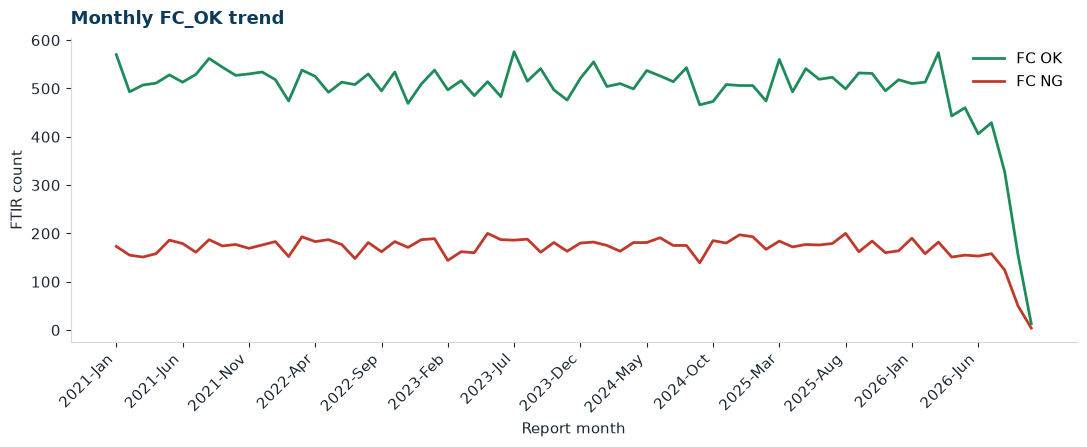

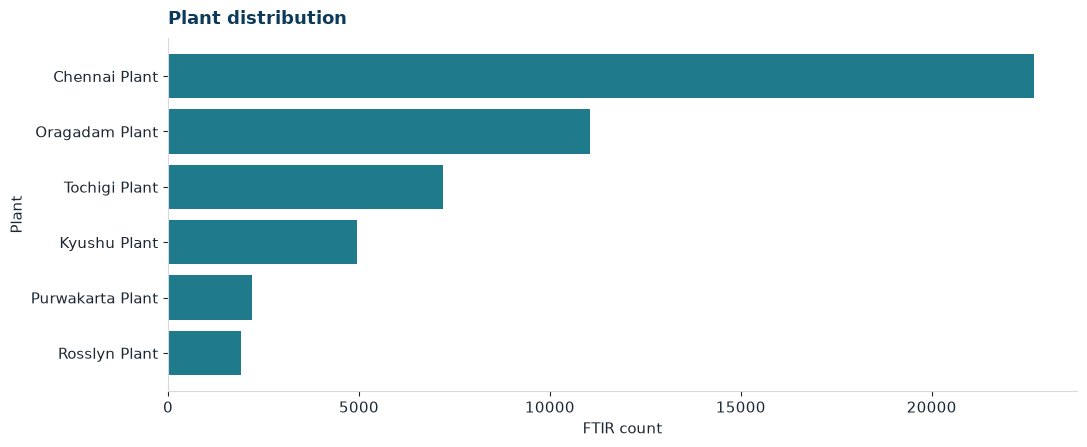

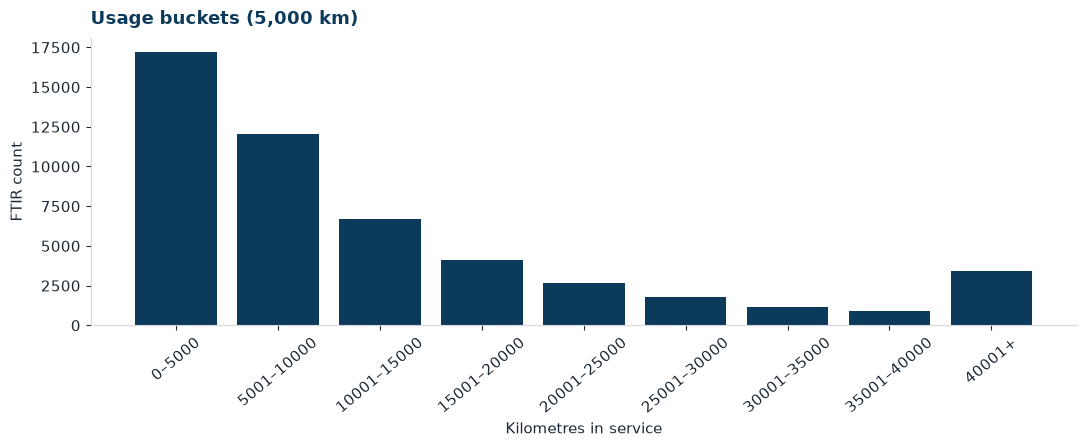

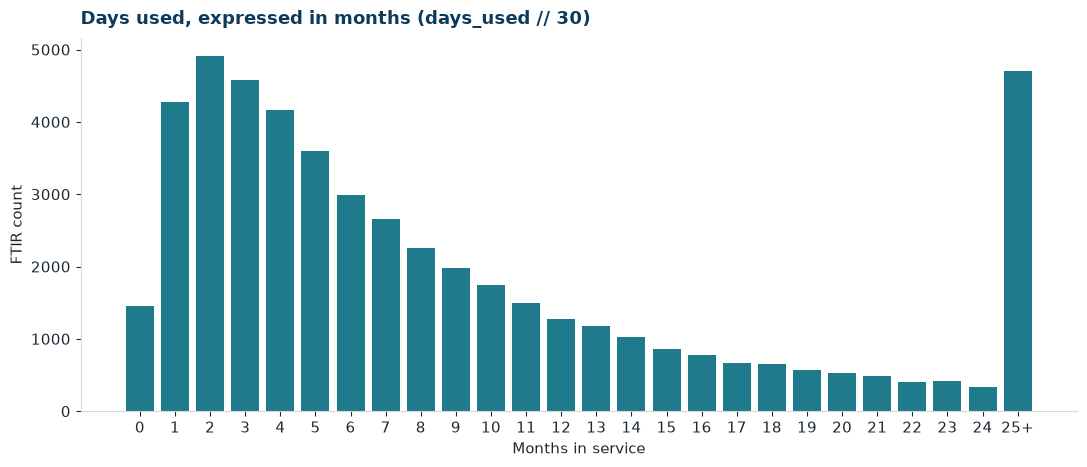

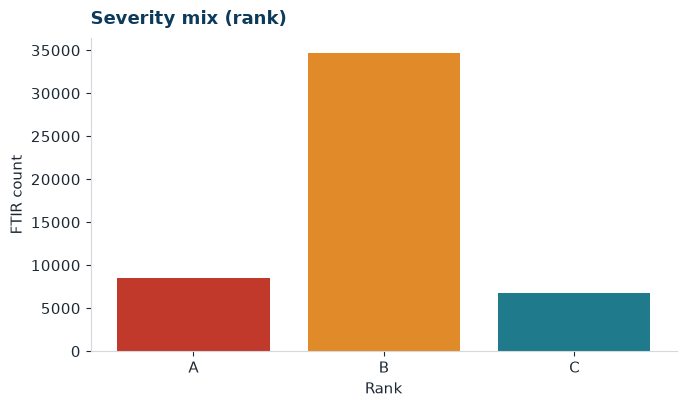

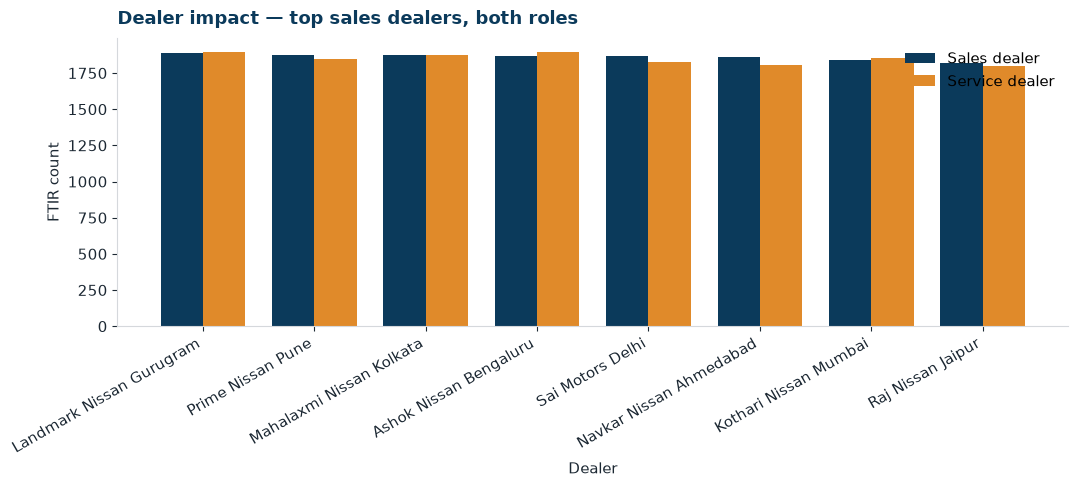

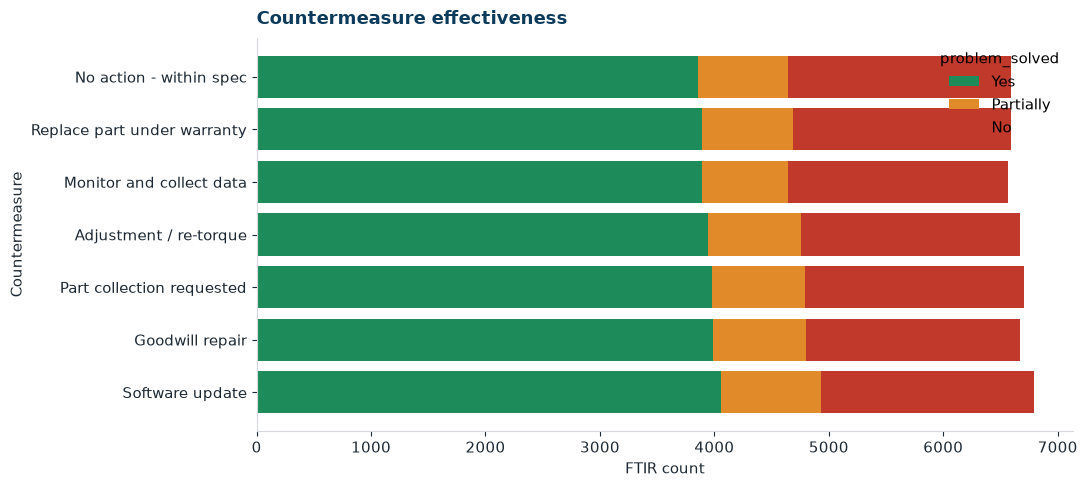

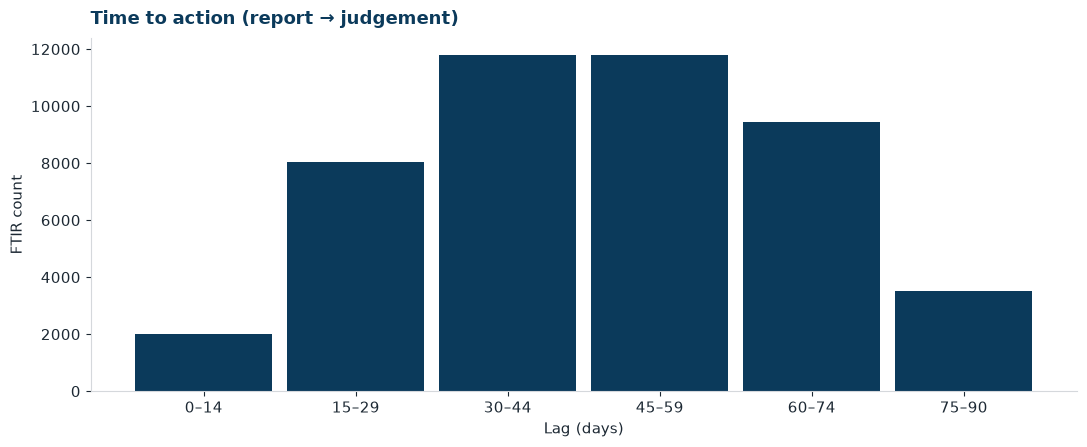

In [17]:
def style_axes(ax, title, xlabel, ylabel):
    ax.set_title(title, loc="left", pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)


# --- Monthly FC_OK trend -------------------------------------------------
monthly = (
    df.dropna(subset=["ftir_report_date"])
    .assign(month_start=lambda x: x["ftir_report_date"].dt.to_period("M").dt.to_timestamp())
    .pivot_table(index="month_start", columns="fc_ok", values="ftir_no", aggfunc="count", fill_value=0)
    .sort_index()
)
for col in ("OK", "NG"):
    if col not in monthly.columns:
        monthly[col] = 0
monthly_labels = monthly.index.strftime("%Y-%b")

fig, ax = plt.subplots()
ax.plot(monthly_labels, monthly["OK"], color=GREEN, lw=2.0, label="FC OK")
ax.plot(monthly_labels, monthly["NG"], color=RED, lw=2.0, label="FC NG")
style_axes(ax, "Monthly FC_OK trend", "Report month", "FTIR count")
ax.legend(frameon=False)
step = max(1, len(monthly_labels) // 12)
ax.set_xticks(range(0, len(monthly_labels), step))
ax.set_xticklabels(monthly_labels[::step], rotation=45, ha="right")
fig.tight_layout()
plt.show()

# --- Plant distribution --------------------------------------------------
plant_plot = plant_counts.sort_values(ascending=True)
fig, ax = plt.subplots()
ax.barh(plant_plot.index, plant_plot.values, color=TEAL)
style_axes(ax, "Plant distribution", "FTIR count", "Plant")
fig.tight_layout()
plt.show()

# --- Usage buckets -------------------------------------------------------
usage_chart = (
    df.groupby("usage_bucket_chart")
    .size()
    .rename("complaints")
    .reset_index()
)
usage_chart["ord"] = usage_chart["usage_bucket_chart"].map(bucket_lower)
usage_chart = usage_chart.sort_values("ord")

fig, ax = plt.subplots()
ax.bar(usage_chart["usage_bucket_chart"], usage_chart["complaints"], color=NAVY)
style_axes(ax, "Usage buckets (5,000 km)", "Kilometres in service", "FTIR count")
ax.tick_params(axis="x", rotation=40)
fig.tight_layout()
plt.show()

# --- Months in service ---------------------------------------------------
def month_chart_label(months) -> str:
    if pd.isna(months):
        return "Unknown"
    months = int(months)
    return "25+" if months >= 25 else str(months)

month_chart = (
    df.assign(month_label=df["months_used"].map(month_chart_label))
    .groupby("month_label")
    .size()
    .rename("complaints")
    .reset_index()
)

def month_label_order(label: str) -> int:
    return 25 if label == "25+" else int(label)

month_chart["ord"] = month_chart["month_label"].map(month_label_order)
month_chart = month_chart.sort_values("ord")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(month_chart["month_label"], month_chart["complaints"], color=TEAL)
style_axes(ax, "Days used, expressed in months (days_used // 30)", "Months in service", "FTIR count")
fig.tight_layout()
plt.show()

# --- Severity ------------------------------------------------------------
rank_plot = rank_kpi[rank_kpi["rank"].isin(["A", "B", "C"])]
fig, ax = plt.subplots(figsize=(7, 4.2))
colors = {"A": RED, "B": AMBER, "C": TEAL}
ax.bar(rank_plot["rank"], rank_plot["complaints"], color=[colors[r] for r in rank_plot["rank"]])
style_axes(ax, "Severity mix (rank)", "Rank", "FTIR count")
fig.tight_layout()
plt.show()

# --- Dealer impact -------------------------------------------------------
top_dealers = sales_counts.head(8).index.tolist()
dealer_chart = pd.DataFrame({
    "dealer": top_dealers,
    "sales_dealer": [int(sales_counts.get(d, 0)) for d in top_dealers],
    "service_dealer": [int(service_counts.get(d, 0)) for d in top_dealers],
})
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(dealer_chart))
width = 0.38
ax.bar(x - width / 2, dealer_chart["sales_dealer"], width, color=NAVY, label="Sales dealer")
ax.bar(x + width / 2, dealer_chart["service_dealer"], width, color=AMBER, label="Service dealer")
ax.set_xticks(x)
ax.set_xticklabels(dealer_chart["dealer"], rotation=30, ha="right")
style_axes(ax, "Dealer impact — top sales dealers, both roles", "Dealer", "FTIR count")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# --- Countermeasure effectiveness ----------------------------------------
solved_order = [c for c in ("Yes", "Partially", "No") if c in measure_kpi.columns]
measure_chart = measure_kpi[solved_order].sort_values("Yes", ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
left = np.zeros(len(measure_chart))
palette = {"Yes": GREEN, "Partially": AMBER, "No": RED}
for col in solved_order:
    ax.barh(measure_chart.index, measure_chart[col], left=left, color=palette[col], label=col)
    left = left + measure_chart[col].to_numpy()
style_axes(ax, "Countermeasure effectiveness", "FTIR count", "Countermeasure")
ax.legend(frameon=False, title="problem_solved")
fig.tight_layout()
plt.show()

# --- Time to action ------------------------------------------------------
lag_bins = [0, 15, 30, 45, 60, 75, 91]
lag_labels = ["0–14", "15–29", "30–44", "45–59", "60–74", "75–90"]
lag_cut = pd.cut(lag, bins=lag_bins, right=False, labels=lag_labels)
lag_chart = lag_cut.value_counts().reindex(lag_labels).fillna(0).astype(int)

fig, ax = plt.subplots()
ax.bar(lag_chart.index.astype(str), lag_chart.values, color=NAVY, width=0.9)
style_axes(ax, "Time to action (report → judgement)", "Lag (days)", "FTIR count")
fig.tight_layout()
plt.show()


## Insights

Statements are computed from this extract. A drop in resolution after 12 months is claimed only when the later rate is at least 5 percentage points lower.


In [18]:
def build_insights(k: dict) -> list[str]:
    notes = []
    share = k["top_failure_share"]
    plant = k["top_failure_plant"]
    if share >= 0.30:
        notes.append(
            f"{plant} accounts for {share:.0%} of failures — systemic concentration, not a one-off dealer event."
        )
    else:
        notes.append(f"{plant} is the largest failure source at {share:.0%} of NG cases.")

    if k["share_gt_20k"] > k["share_le_10k"]:
        notes.append(
            f"High mileage buckets (>20,000 km) hold more of the file ({k['share_gt_20k']:.0%}) "
            f"than the 0–10,000 km bands ({k['share_le_10k']:.0%})."
        )
    else:
        notes.append(
            f"Complaints concentrate early in life: {k['share_le_10k']:.0%} sit in the 0–10,000 km buckets, "
            f"while mileage above 20,000 km accounts for {k['share_gt_20k']:.0%}."
        )

    early_rate, late_rate = k["resolution_0_12"], k["resolution_13_plus"]
    if late_rate < early_rate - 0.05:
        notes.append(
            f"Resolution rate drops after 12 months of usage "
            f"({early_rate:.0%} through month 12 vs {late_rate:.0%} afterward)."
        )
    elif late_rate > early_rate + 0.05:
        notes.append(
            f"Resolution rate is higher after 12 months ({late_rate:.0%}) than in the first year ({early_rate:.0%})."
        )
    else:
        notes.append(
            f"Resolution rate holds near {early_rate:.0%} through 12 months and {late_rate:.0%} after that — "
            "months in service are not what separates closed from open cases."
        )

    notes.append(
        f"A countermeasure other than \"No action - within spec\" is recorded in {k['action_rate']:.0%} of cases, "
        f"and {k['action_solved']:.0%} of those are marked solved "
        f"(solved rate with no action: {k['no_action_solved']:.0%}; overall {k['solved_rate']:.0%})."
    )
    notes.append(
        f"Average investigation lag from report to judgement is {k['avg_lag']:.0f} days "
        f"(median {k['median_lag']:.0f}, n={k['n_lag']:,})."
    )
    notes.append(
        f"Severity rank {k['top_rank']} is {k['top_rank_share']:.0%} of the file "
        f"(A {k['rank_shares'].get('A', 0):.0%}, B {k['rank_shares'].get('B', 0):.0%}, "
        f"C {k['rank_shares'].get('C', 0):.0%})."
    )
    return notes


def build_recommendations(k: dict) -> list[str]:
    recs = [
        f"Start the plant review at {k['top_failure_plant']} ({k['top_failure_share']:.0%} of NG). "
        "Compare its top subjects and causal parts with the next plant before treating the gap as volume only.",
        "Put the early-usage population first: most FTIR volume is under 10,000 km, so Pareto the subjects inside the 0–5000 and 5001–10000 buckets.",
        "Solved rate barely moves between countermeasure types. Audit whether problem_solved is updated after the measure, and whether the measure matches the checked result.",
        f"Investigation lag averages {k['avg_lag']:.0f} days. A 30-day judgement target would cut about "
        f"{max(k['avg_lag'] - 30, 0):.0f} days off the current mean.",
        f"Rank {k['top_rank']} is the volume rank. Keep rank A on a separate weekly list so it is not averaged into the B-rank majority.",
    ]
    return recs


insights = build_insights(kpi)
recommendations = build_recommendations(kpi)

print("Insights")
for line in insights:
    print(f"• {line}")
print("\nRecommendations")
for line in recommendations:
    print(f"• {line}")


Insights
• Chennai Plant accounts for 45% of failures — systemic concentration, not a one-off dealer event.
• Complaints concentrate early in life: 59% sit in the 0–10,000 km buckets, while mileage above 20,000 km accounts for 20%.
• Resolution rate holds near 55% through 12 months and 55% after that — months in service are not what separates closed from open cases.
• A countermeasure other than "No action - within spec" is recorded in 86% of cases, and 55% of those are marked solved (solved rate with no action: 55%; overall 55%).
• Average investigation lag from report to judgement is 46 days (median 46, n=46,596).
• Severity rank A is 17% of the file (A 17%, B 69%, C 14%).

Recommendations
• Start the plant review at Chennai Plant (45% of NG). Compare its top subjects and causal parts with the next plant before treating the gap as volume only.
• Put the early-usage population first: most FTIR volume is under 10,000 km, so Pareto the subjects inside the 0–5000 and 5001–10000 buckets.


## Editable PowerPoint

Charts are Office chart objects (`python-pptx` `CategoryChartData`). Open the file in PowerPoint and use **Edit Data** to change values. Nothing is pasted as a picture.


In [20]:
RGB = {
    "navy": RGBColor(0x0B, 0x3A, 0x5B),
    "teal": RGBColor(0x1F, 0x7A, 0x8C),
    "amber": RGBColor(0xE0, 0x8A, 0x2A),
    "green": RGBColor(0x1E, 0x8C, 0x5A),
    "red": RGBColor(0xC0, 0x39, 0x2B),
    "slate": RGBColor(0x5D, 0x6D, 0x7E),
    "white": RGBColor(0xFF, 0xFF, 0xFF),
    "ink": RGBColor(0x1C, 0x28, 0x33),
    "paper": RGBColor(0xF4, 0xF7, 0xF8),
}


def _rgb_fill(shape, color: RGBColor):
    shape.fill.solid()
    shape.fill.fore_color.rgb = color
    shape.line.fill.background()


def add_title_bar(slide, prs, title: str, subtitle: str | None = None):
    bar = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, 0, prs.slide_width, Inches(0.92))
    _rgb_fill(bar, RGB["navy"])
    box = slide.shapes.add_textbox(Inches(0.45), Inches(0.16), Inches(12.4), Inches(0.42))
    p = box.text_frame.paragraphs[0]
    p.text = title
    p.font.size = Pt(26)
    p.font.bold = True
    p.font.color.rgb = RGB["white"]
    p.font.name = "Calibri"
    if subtitle:
        sub = slide.shapes.add_textbox(Inches(0.45), Inches(0.54), Inches(12.4), Inches(0.30))
        sp = sub.text_frame.paragraphs[0]
        sp.text = subtitle
        sp.font.size = Pt(12)
        sp.font.color.rgb = RGBColor(0xD6, 0xE0, 0xE6)
        sp.font.name = "Calibri"


def add_bullets(slide, left, top, width, height, items, size=13, color=None, space_after=8):
    box = slide.shapes.add_textbox(Inches(left), Inches(top), Inches(width), Inches(height))
    tf = box.text_frame
    tf.word_wrap = True
    for i, item in enumerate(items):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.text = item
        p.level = 0
        p.font.size = Pt(size)
        p.font.name = "Calibri"
        p.font.color.rgb = color or RGB["ink"]
        p.space_after = Pt(space_after)
        p.line_spacing = 1.0
    return box


def color_series(series, color: RGBColor, line=False):
    fill = series.format.fill
    fill.solid()
    fill.fore_color.rgb = color
    series.format.line.color.rgb = color
    if line:
        series.format.line.width = Pt(2.25)


def style_chart(chart, legend=False, value_title=None, label_size=9):
    chart.has_legend = legend
    if legend:
        chart.legend.include_in_layout = False
        chart.legend.position = XL_LEGEND_POSITION.BOTTOM
        chart.legend.font.size = Pt(11)
        chart.legend.font.name = "Calibri"
    chart.has_title = False
    chart.font.name = "Calibri"
    chart.font.size = Pt(10)
    category_axis = chart.category_axis
    category_axis.tick_labels.font.size = Pt(label_size)
    category_axis.tick_labels.font.name = "Calibri"
    category_axis.tick_labels.font.color.rgb = RGB["ink"]
    category_axis.has_major_gridlines = False
    value_axis = chart.value_axis
    value_axis.tick_labels.font.size = Pt(10)
    value_axis.tick_labels.font.name = "Calibri"
    value_axis.tick_labels.font.color.rgb = RGB["slate"]
    value_axis.has_major_gridlines = True
    value_axis.major_gridlines.format.line.color.rgb = RGBColor(0xE5, 0xE8, 0xEB)
    value_axis.format.line.color.rgb = RGBColor(0xD5, 0xD8, 0xDC)
    if value_title:
        value_axis.has_title = True
        vp = value_axis.axis_title.text_frame.paragraphs[0]
        vp.text = value_title
        vp.font.size = Pt(10)
        vp.font.color.rgb = RGB["slate"]
        vp.font.name = "Calibri"


def add_chart(slide, chart_type, categories, series, left, top, width, height, colors, legend=False, value_title=None, label_size=9):
    data = CategoryChartData()
    data.categories = [str(c) for c in categories]
    for name, values in series:
        data.add_series(name, tuple(float(v) for v in values))
    frame = slide.shapes.add_chart(
        chart_type, Inches(left), Inches(top), Inches(width), Inches(height), data
    )
    chart = frame.chart
    style_chart(chart, legend=legend, value_title=value_title, label_size=label_size)
    for series_obj, color in zip(chart.series, colors):
        color_series(series_obj, color, line=(chart_type == XL_CHART_TYPE.LINE))
    return chart


def kpi_bullets(k: dict) -> list[str]:
    return [
        f"{k['n']:,} FTIR rows, {k['date_min']:%b %Y} to {k['date_max']:%b %Y}.",
        f"Failures (NG): {k['n_fail']:,} ({k['fail_rate']:.0%} of rows).",
        f"{k['top_failure_plant']}: {k['top_failure_share']:.0%} of failures ({k['top_failure_count']:,} NG).",
        f"Largest usage bucket {k['top_usage_bucket']}: {k['top_usage_share']:.0%} of complaints. "
        f"0–10,000 km is {k['share_le_10k']:.0%}; above 20,000 km is {k['share_gt_20k']:.0%}.",
        f"Resolution rate {k['resolution_rate']:.0%} overall; {k['resolution_0_12']:.0%} in months 0–12 "
        f"and {k['resolution_13_plus']:.0%} after month 12.",
        f"Severity: A {k['rank_shares'].get('A', 0):.0%}, B {k['rank_shares'].get('B', 0):.0%}, "
        f"C {k['rank_shares'].get('C', 0):.0%}.",
        f"Top sales dealer {k['top_sales_dealer']} ({k['top_sales_count']:,}). "
        f"Top service dealer {k['top_service_dealer']} ({k['top_service_count']:,}). "
        f"Same dealer on both roles in {k['same_dealer_share']:.0%} of rows.",
        f"Countermeasure recorded (excluding no-action) in {k['action_rate']:.0%} of rows; "
        f"solved rate on those rows {k['action_solved']:.0%}.",
        f"Mean investigation lag {k['avg_lag']:.0f} days (median {k['median_lag']:.0f}).",
    ]


prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)
blank = prs.slide_layouts[6]

# Title
slide = prs.slides.add_slide(blank)
_rgb_fill(slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, 0, prs.slide_width, prs.slide_height), RGB["navy"])
accent = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, Inches(4.55), prs.slide_width, Inches(0.08))
_rgb_fill(accent, RGB["amber"])
title_box = slide.shapes.add_textbox(Inches(0.7), Inches(2.15), Inches(11.5), Inches(1.4))
tp = title_box.text_frame.paragraphs[0]
tp.text = "FTIR Automated KPI Report – 2026"
tp.font.size = Pt(40)
tp.font.bold = True
tp.font.color.rgb = RGB["white"]
tp.font.name = "Calibri"
sub = slide.shapes.add_textbox(Inches(0.7), Inches(3.65), Inches(11), Inches(0.7))
sp = sub.text_frame.paragraphs[0]
sp.text = (
    f"{kpi['n']:,} field reports  ·  {kpi['date_min']:%b %Y} – {kpi['date_max']:%b %Y}"
    f"  ·  Source: {DATA_PATH.name}"
)
sp.font.size = Pt(16)
sp.font.color.rgb = RGBColor(0xD6, 0xE0, 0xE6)
sp.font.name = "Calibri"
foot = slide.shapes.add_textbox(Inches(0.7), Inches(6.55), Inches(11), Inches(0.4))
fp = foot.text_frame.paragraphs[0]
fp.text = "Charts on the following slides are editable PowerPoint objects."
fp.font.size = Pt(13)
fp.font.color.rgb = RGBColor(0xAE, 0xC0, 0xC9)
fp.font.name = "Calibri"

# 1. Monthly trend
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Monthly FC_OK trend", "Count of FTIR rows by report month and fc_ok")
add_chart(
    slide, XL_CHART_TYPE.LINE,
    monthly_labels.tolist(),
    [("FC OK", monthly["OK"].tolist()), ("FC NG", monthly["NG"].tolist())],
    0.35, 1.15, 9.15, 5.95,
    [RGB["green"], RGB["red"]],
    legend=True, value_title="FTIR count", label_size=8,
)
add_bullets(slide, 9.65, 1.35, 3.35, 5.4, [
    f"NG share of the file is {kpi['fail_rate']:.0%}.",
    f"Span {kpi['date_min']:%Y-%b} to {kpi['date_max']:%Y-%b}.",
    "OK and NG are plotted as separate series so a volume spike is not read as a quality shift.",
])

# 2. Plant
plant_desc = plant_counts.sort_values(ascending=False)
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Plant distribution", "manufacturer_factory, all FTIR rows")
add_chart(
    slide, XL_CHART_TYPE.COLUMN_CLUSTERED,
    plant_desc.index.tolist(),
    [("Complaints", plant_desc.values.tolist())],
    0.35, 1.15, 9.15, 5.95,
    [RGB["teal"]],
    value_title="FTIR count",
)
plant_lines = [
    f"{idx}: {plant_kpi.loc[idx, 'pct_of_failures']:.0%} of NG ({int(plant_kpi.loc[idx, 'failures_ng']):,})"
    for idx in plant_kpi.index
]
add_bullets(slide, 9.65, 1.25, 3.35, 5.6, ["Share of failures (NG)"] + plant_lines, size=12)

# 3. Usage
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Usage buckets", "using_km_int in 5,000 km bands; 40,001 km and above grouped")
add_chart(
    slide, XL_CHART_TYPE.COLUMN_CLUSTERED,
    usage_chart["usage_bucket_chart"].tolist(),
    [("Complaints", usage_chart["complaints"].tolist())],
    0.35, 1.15, 9.15, 5.95,
    [RGB["navy"]],
    value_title="FTIR count", label_size=10,
)
add_bullets(slide, 9.65, 1.35, 3.35, 5.4, [
    f"0–10,000 km: {kpi['share_le_10k']:.0%} of complaints.",
    f"Above 20,000 km: {kpi['share_gt_20k']:.0%}.",
    "The full 5,000 km table, including the tail, is in the notebook KPI section.",
])

# 4. Months used
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Days used (months)", "months = days_used // 30; month 25 and later grouped")
add_chart(
    slide, XL_CHART_TYPE.COLUMN_CLUSTERED,
    month_chart["month_label"].tolist(),
    [("Complaints", month_chart["complaints"].tolist())],
    0.35, 1.15, 9.15, 5.95,
    [RGB["teal"]],
    value_title="FTIR count", label_size=9,
)
add_bullets(slide, 9.65, 1.35, 3.35, 5.4, [
    f"Resolution, months 0–12: {kpi['resolution_0_12']:.0%} (n={kpi['n_0_12']:,}).",
    f"Resolution after month 12: {kpi['resolution_13_plus']:.0%} (n={kpi['n_13_plus']:,}).",
    "Volume falls as months in service rise; the rate does the explaining, not the bar height alone.",
])

# 5. Severity
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Severity mix", "rank A / B / C")
add_chart(
    slide, XL_CHART_TYPE.COLUMN_CLUSTERED,
    rank_plot["rank"].tolist(),
    [("Complaints", rank_plot["complaints"].tolist())],
    0.35, 1.15, 8.4, 5.95,
    [RGB["navy"]],
    value_title="FTIR count",
)
add_bullets(slide, 9.0, 1.5, 3.9, 4.8, [
    f"A: {kpi['rank_shares'].get('A', 0):.0%}",
    f"B: {kpi['rank_shares'].get('B', 0):.0%}",
    f"C: {kpi['rank_shares'].get('C', 0):.0%}",
    "B is the working volume. A still needs its own review queue.",
], size=16)

# 6. Dealers
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Dealer impact", "Top 8 sales dealers, counted again in the service-dealer role")
add_chart(
    slide, XL_CHART_TYPE.COLUMN_CLUSTERED,
    dealer_chart["dealer"].tolist(),
    [
        ("Sales dealer", dealer_chart["sales_dealer"].tolist()),
        ("Service dealer", dealer_chart["service_dealer"].tolist()),
    ],
    0.35, 1.15, 9.15, 5.95,
    [RGB["navy"], RGB["amber"]],
    legend=True, value_title="FTIR count", label_size=9,
)
add_bullets(slide, 9.65, 1.35, 3.35, 5.4, [
    f"Top sales: {kpi['top_sales_dealer']} ({kpi['top_sales_count']:,}).",
    f"Top service: {kpi['top_service_dealer']} ({kpi['top_service_count']:,}).",
    f"Sales and service dealer match on {kpi['same_dealer_share']:.0%} of rows.",
    "Counts are close across dealers; no single outlet dominates the file.",
], size=13)

# 7. Countermeasures — stacked columns (editable)
measure_plot = measure_kpi.sort_values("complaints", ascending=False)
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Countermeasure effectiveness", "c_measure by problem_solved")
cm_colors = {"Yes": RGB["green"], "Partially": RGB["amber"], "No": RGB["red"]}
add_chart(
    slide, XL_CHART_TYPE.COLUMN_STACKED,
    measure_plot.index.tolist(),
    [(col, measure_plot[col].tolist()) for col in solved_order],
    0.3, 1.15, 9.2, 5.95,
    [cm_colors[c] for c in solved_order],
    legend=True, value_title="FTIR count", label_size=9,
)
add_bullets(slide, 9.65, 1.35, 3.35, 5.4, [
    f"Action recorded: {kpi['action_rate']:.0%} of rows.",
    f"Solved given an action: {kpi['action_solved']:.0%}.",
    f"Solved given no action: {kpi['no_action_solved']:.0%}.",
    "Success is the Yes share. Partially stays in the stack so it is not treated as closed.",
], size=13)

# 8. Time to action — binned column chart (editable histogram)
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Time to action", "Days from ftir_report_date to judgement_date")
add_chart(
    slide, XL_CHART_TYPE.COLUMN_CLUSTERED,
    lag_chart.index.astype(str).tolist(),
    [("FTIR count", lag_chart.values.tolist())],
    0.35, 1.15, 9.15, 5.95,
    [RGB["navy"]],
    value_title="FTIR count",
)
add_bullets(slide, 9.65, 1.35, 3.35, 5.4, [
    f"Mean lag {kpi['avg_lag']:.0f} days.",
    f"Median lag {kpi['median_lag']:.0f} days.",
    f"Rows with both dates: {kpi['n_lag']:,}.",
    "Bins are an editable column chart so the histogram can be revised in PowerPoint.",
])

# Insights and recommendations (summary + narrative)
slide = prs.slides.add_slide(blank)
add_title_bar(slide, prs, "Insights & Recommendations", "Figures are calculated from this extract")
panel_l = slide.shapes.add_shape(MSO_SHAPE.ROUNDED_RECTANGLE, Inches(0.35), Inches(1.15), Inches(6.25), Inches(5.95))
_rgb_fill(panel_l, RGB["paper"])
panel_r = slide.shapes.add_shape(MSO_SHAPE.ROUNDED_RECTANGLE, Inches(6.75), Inches(1.15), Inches(6.2), Inches(5.95))
_rgb_fill(panel_r, RGB["paper"])
h1 = slide.shapes.add_textbox(Inches(0.55), Inches(1.28), Inches(5.9), Inches(0.36))
hp = h1.text_frame.paragraphs[0]
hp.text = "KPI summary"
hp.font.size = Pt(16)
hp.font.bold = True
hp.font.color.rgb = RGB["navy"]
hp.font.name = "Calibri"
h2 = slide.shapes.add_textbox(Inches(6.95), Inches(1.28), Inches(5.8), Inches(0.36))
hp2 = h2.text_frame.paragraphs[0]
hp2.text = "Insights and recommendations"
hp2.font.size = Pt(16)
hp2.font.bold = True
hp2.font.color.rgb = RGB["navy"]
hp2.font.name = "Calibri"
add_bullets(slide, 0.55, 1.72, 5.85, 5.15, kpi_bullets(kpi), size=11, space_after=4)
add_bullets(slide, 6.95, 1.72, 5.8, 5.15, insights + recommendations, size=11, space_after=4)

out_dir = Path.cwd() / "output"
if not out_dir.is_dir():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "data").is_dir():
            out_dir = parent / "output"
            break
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "FTIR_Automated_KPI_Report_2026.pptx"
prs.save(out_path)
print(f"Saved {out_path}")


Saved d:\MQIH2\output\FTIR_Automated_KPI_Report_2026.pptx
